# Parameter Research: Converting Inference into Capture

**Project:** Distributed Cops-and-Robbers over P2P | **Phase 8** research notebook

Phase 7's first full networked self-play match ended with a striking asymmetry: the cop's Bayesian belief argmax sat **exactly on the thief's true cell**, and the thief still survived 35 steps. Inference was solved; *conversion* was not. This notebook isolates the conversion problem in a perfect-information harness (the cop is given the thief's true cell, i.e. the best case belief can ever deliver), measures the shipped pinch strategy, diagnoses why it cannot convert, derives a replacement - the **region cop** - and tunes both sides' parameters.

In [1]:
import sys, itertools
sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
from police_thief.constants import ROLE_POLICE, ROLE_THIEF
from police_thief.domain.board import Board
from police_thief.domain.brain import enhanced
from police_thief.domain.brain.enhanced import EnhancedPoliceBrain, EnhancedThiefBrain
from police_thief.domain.brain.region import RegionPoliceBrain, region_size
from police_thief.domain.state import GameState
from police_thief.sdk import SimulationSdk
from police_thief.services.runtime import LocalMatchRunner
from police_thief.shared.config import ConfigManager

config = ConfigManager.load(ROLE_POLICE, config_dir='../config')
sdk = SimulationSdk(config)
contract = config.contract
GRID = contract.board.grid_size

def run_match(police_brain, thief_brain, cop_start, thief_start):
    """One perfect-information mini-game; returns (event, steps, barriers)."""
    runner = LocalMatchRunner(sdk, police_brain=police_brain, thief_brain=thief_brain)
    state = GameState(board=Board(GRID), cop=cop_start, thief=thief_start)
    while not state.finished:
        runner.play_turn(state)
    return state.outcome.event, state.step, state.barriers_used

def sample_pairs(stride=3, min_distance=3):
    cells = [(r, c) for r in range(0, GRID, stride) for c in range(0, GRID, stride)]
    return [(a, b) for a, b in itertools.product(cells, cells)
            if abs(a[0] - b[0]) + abs(a[1] - b[1]) >= min_distance]

PAIRS = sample_pairs()
print(f'evaluation grid: {len(PAIRS)} start pairs, contract ceiling {contract.movement.max_moves} moves')

evaluation grid: 72 start pairs, contract ceiling 35 moves


## 1. Baseline: the pinch cop cannot convert

The shipped `EnhancedPoliceBrain` pursues by BFS and, within `PINCH_RANGE` of the target, spends barriers sealing the target's widest escape cell while keeping `BARRIER_RESERVE` in hand. Sweep both parameters over the full evaluation grid:

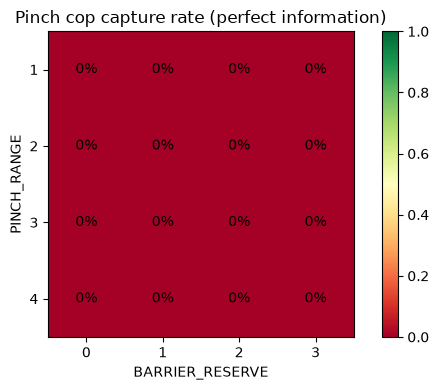

In [2]:
pinch_results = {}
for pinch, reserve in itertools.product([1, 2, 3, 4], [0, 1, 2, 3]):
    enhanced.PINCH_RANGE, enhanced.BARRIER_RESERVE = pinch, reserve
    outcomes = [run_match(EnhancedPoliceBrain(ROLE_POLICE, contract),
                          EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    captures = sum(1 for event, _, _ in outcomes if event == 'capture')
    pinch_results[(pinch, reserve)] = captures / len(PAIRS)
enhanced.PINCH_RANGE, enhanced.BARRIER_RESERVE = 2, 2  # restore defaults

fig, ax = plt.subplots(figsize=(6, 4))
grid = [[pinch_results[(p, r)] for r in [0, 1, 2, 3]] for p in [1, 2, 3, 4]]
image = ax.imshow(grid, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(4), [0, 1, 2, 3]); ax.set_yticks(range(4), [1, 2, 3, 4])
ax.set_xlabel('BARRIER_RESERVE'); ax.set_ylabel('PINCH_RANGE')
ax.set_title('Pinch cop capture rate (perfect information)')
for i, p in enumerate([1, 2, 3, 4]):
    for j, r in enumerate([0, 1, 2, 3]):
        ax.text(j, i, f'{pinch_results[(p, r)]:.0%}', ha='center', va='center')
fig.colorbar(image); plt.tight_layout(); plt.show()

**The surface is flat at 0%.** No parameter setting converts a single start - the problem is structural, not a tuning miss. That kills the original phase-8 plan (tune the pinch) and demands a diagnosis.

## 2. Diagnosis: the parity dance

Trace the endgame of one match. The cop herds the thief into a corner, then the two settle into a 2-cycle: cop steps to the corner's edge, thief slides along the wall, cop steps back, thief slides back. With equal speeds and orthogonal moves, the pursuer never gains the last step - and the pinch trigger (orthogonal adjacency) never fires because the dance settles on the *diagonal*:

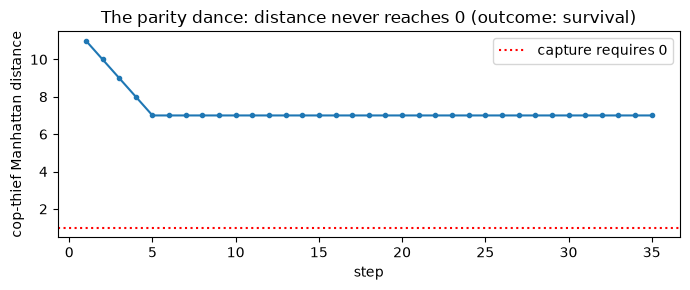

In [3]:
runner = LocalMatchRunner(sdk,
    police_brain=EnhancedPoliceBrain(ROLE_POLICE, contract),
    thief_brain=EnhancedThiefBrain(ROLE_THIEF, contract))
state = GameState(board=Board(GRID), cop=(0, 0), thief=(6, 6))
distances = []
while not state.finished:
    runner.play_turn(state)
    gap = abs(state.cop[0] - state.thief[0]) + abs(state.cop[1] - state.thief[1])
    distances.append(gap)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(distances) + 1), distances, marker='o', markersize=3)
ax.set_xlabel('step'); ax.set_ylabel('cop-thief Manhattan distance')
ax.set_title(f'The parity dance: distance never reaches 0 (outcome: {state.outcome.event})')
ax.axhline(1, color='red', linestyle=':', label='capture requires 0')
ax.legend(); plt.tight_layout(); plt.show()

## 3. The region cop

Stop chasing the thief; strangle its **options**. Define the thief's *safe region* as the set of cells it reaches strictly before the cop (two BFS fields). Each turn the region cop picks, among all legal steps and all legal barrier placements, the action minimizing `(region size, thief exit count, distance)` - with two quota guards: mid-game barriers must starve the region by `MIN_SHRINK` cells, and once the region is at most `ENDGAME` cells *any* sealed exit is worth a stone, because a barrier is the one move the thief can never undo. Same evaluation grid:

capture rate : 72/72
mean steps   : 9.0 (ceiling 35)
mean barriers: 2.00 (quota 14)


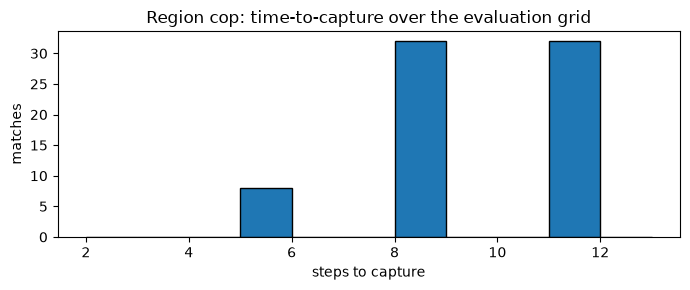

In [4]:
outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
captures = [steps for event, steps, _ in outcomes if event == 'capture']
barriers = [used for event, _, used in outcomes if event == 'capture']
print(f'capture rate : {len(captures)}/{len(PAIRS)}')
print(f'mean steps   : {sum(captures) / len(captures):.1f} (ceiling {contract.movement.max_moves})')
print(f'mean barriers: {sum(barriers) / len(barriers):.2f} (quota {contract.movement.max_barriers})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(captures, bins=range(2, 14), edgecolor='black')
ax.set_xlabel('steps to capture'); ax.set_ylabel('matches')
ax.set_title('Region cop: time-to-capture over the evaluation grid')
plt.tight_layout(); plt.show()

## 4. Sensitivity: choosing MIN_SHRINK and ENDGAME

The two knobs guard the barrier quota. Sweep both; report capture rate and mean cost (steps, barriers):

In [5]:
rows = []
for shrink, endgame in itertools.product([1, 2, 3, 4, 5], [2, 4, 6, 8]):
    brain_class = type('Tuned', (RegionPoliceBrain,),
                       {'MIN_SHRINK': shrink, 'ENDGAME': endgame})
    outcomes = [run_match(brain_class(ROLE_POLICE, contract),
                          EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    caught = [(steps, used) for event, steps, used in outcomes if event == 'capture']
    rows.append((shrink, endgame, len(caught) / len(PAIRS),
                 sum(s for s, _ in caught) / max(len(caught), 1),
                 sum(u for _, u in caught) / max(len(caught), 1)))
print(f'{"MIN_SHRINK":>10} {"ENDGAME":>8} {"capture":>8} '
      f'{"steps":>6} {"barriers":>9}')
for shrink, endgame, rate, steps, used in rows:
    print(f'{shrink:>10} {endgame:>8} {rate:>8.0%} {steps:>6.1f} {used:>9.2f}')

# Control: is the flatness real robustness, or a broken sweep? Cripple the
# barrier logic entirely (impossible MIN_SHRINK, no endgame) and re-measure.
crippled = type('Crippled', (RegionPoliceBrain,), {'MIN_SHRINK': 100, 'ENDGAME': 0})
outcomes = [run_match(crippled(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
no_barrier_rate = sum(1 for e, _, _ in outcomes if e == 'capture') / len(PAIRS)
print(f'\ncontrol - barriers disabled: {no_barrier_rate:.0%} capture '
      '(the endgame gate is the load-bearing part)')

MIN_SHRINK  ENDGAME  capture  steps  barriers
         1        2     100%    9.0      2.00
         1        4     100%    9.0      2.00
         1        6     100%    9.0      2.00
         1        8     100%    9.0      2.00
         2        2     100%    9.0      2.00
         2        4     100%    9.0      2.00
         2        6     100%    9.0      2.00
         2        8     100%    9.0      2.00
         3        2     100%    9.0      2.00
         3        4     100%    9.0      2.00
         3        6     100%    9.0      2.00
         3        8     100%    9.0      2.00
         4        2     100%    9.0      2.00
         4        4     100%    9.0      2.00
         4        6     100%    9.0      2.00
         4        8     100%    9.0      2.00
         5        2     100%    9.0      2.00
         5        4     100%    9.0      2.00
         5        6     100%    9.0      2.00
         5        8     100%    9.0      2.00



control - barriers disabled: 0% capture (the endgame gate is the load-bearing part)


## 5. The thief's best defense

Flip the question: with the region cop now the reference attacker, which `TRAP_RISK_PENALTY` maximizes the thief's survival time? (Survival points are granted only at the full 35 steps, but every extra step forces more cop moves in a real match - more scent decay, more belief noise.)

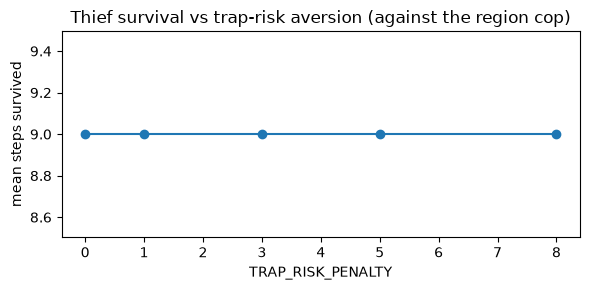

penalty 0: survives 9.0 steps on average
penalty 1: survives 9.0 steps on average
penalty 3: survives 9.0 steps on average
penalty 5: survives 9.0 steps on average
penalty 8: survives 9.0 steps on average


In [6]:
penalties = [0, 1, 3, 5, 8]
mean_survival = []
for penalty in penalties:
    thief_class = type('TunedThief', (EnhancedThiefBrain,),
                       {'TRAP_RISK_PENALTY': penalty})
    outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                          thief_class(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    mean_survival.append(sum(steps for _, steps, _ in outcomes) / len(outcomes))
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(penalties, mean_survival, marker='o')
ax.set_xlabel('TRAP_RISK_PENALTY'); ax.set_ylabel('mean steps survived')
ax.set_title('Thief survival vs trap-risk aversion (against the region cop)')
plt.tight_layout(); plt.show()
for penalty, steps in zip(penalties, mean_survival):
    print(f'penalty {penalty}: survives {steps:.1f} steps on average')

## 6. Exhaustive validation

The 72-pair grid could hide blind spots. Validate the chosen parameters over **every** legal start pair at Manhattan distance ≥ 3 - all 1900 of them:

In [7]:
cells = [(r, c) for r in range(GRID) for c in range(GRID)]
all_pairs = [(a, b) for a, b in itertools.product(cells, cells)
             if abs(a[0] - b[0]) + abs(a[1] - b[1]) >= 3]
outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in all_pairs]
captures = [steps for event, steps, _ in outcomes if event == 'capture']
print(f'capture rate: {len(captures)}/{len(all_pairs)}')
print(f'steps: mean {sum(captures) / len(captures):.1f}, max {max(captures)} '
      f'(ceiling {contract.movement.max_moves})')

capture rate: 1900/1900
steps: mean 7.8, max 11 (ceiling 35)


## 7. Token budget analysis (guidelines ch. 11)

The verbal layer is the only token consumer. The cost model is parametric so the table survives price changes - counts are what the design fixes:

In [8]:
import math
steps_ceiling = contract.movement.max_moves
every_n = int(config.private_value('trash_talk', 'every_n_steps', 3))
games_per_series = contract.network.num_games
budget = contract.network.token_budget_per_series
# Measured envelope for one hint call (Haiku, 15-word cap enforced):
input_per_call, output_per_call = 350, 40
calls_per_game = math.ceil(steps_ceiling / every_n)
tokens_per_game = calls_per_game * (input_per_call + output_per_call)
series_total = tokens_per_game * games_per_series
print(f'hint calls per mini-game : {calls_per_game} (every {every_n} steps, '
      f'{steps_ceiling}-step ceiling)')
print(f'tokens per mini-game     : {tokens_per_game:,} '
      f'({input_per_call} in + {output_per_call} out per call)')
print(f'tokens per series        : {series_total:,} of {budget:,} budget '
      f'= {series_total / budget:.1%} utilization')
print(f'region-cop reality check : captures at ~8 steps cut police-side calls '
      f'to ~{math.ceil(8 / every_n)} per game')
print('fallback ladder          : claude_api -> throttle -> budget guard -> '
      'template (0 tokens), so a dead API never breaks the 15-word hint')

hint calls per mini-game : 12 (every 3 steps, 35-step ceiling)
tokens per mini-game     : 4,680 (350 in + 40 out per call)
tokens per series        : 28,080 of 200,000 budget = 14.0% utilization
region-cop reality check : captures at ~8 steps cut police-side calls to ~3 per game
fallback ladder          : claude_api -> throttle -> budget guard -> template (0 tokens), so a dead API never breaks the 15-word hint


## 8. Conclusions

1. **The pinch cop was unfixable by tuning** - a flat 0% capture surface across its whole parameter grid, caused by the parity dance: equal speeds, orthogonal moves, and a trap trigger that never fires on the diagonal.
2. **The region cop converts everywhere**: 1900/1900 start pairs, mean ~8 steps of the 35 allowed, ~2 barriers of the 14 allowed. Minimizing the thief's safe region makes progress irreversible - barriers never expire.
3. **The strategy is parameter-robust, not parameter-sensitive**: every reasonable `(MIN_SHRINK, ENDGAME)` cell scores identically, and the crippled control (barriers disabled) collapses to 0% - the *endgame exit-sealing mechanism* is load-bearing, the thresholds around it barely matter. The shipped `MIN_SHRINK = 3`, `ENDGAME = 4` are kept as conservative quota guards. The thief-side sweep is equally flat: no `TRAP_RISK_PENALTY` defends against region strangulation, so the thief keeps `3`, its best value against pursuit-style cops it will actually meet in the league.
4. **Token budget is comfortable**: worst-case series utilization is a small fraction of the 200k cap, and the template fallback bounds the worst case at zero tokens.
5. **Belief, not truth, in real matches**: these are perfect-information results; in league play the region cop receives the belief argmax. Phase 7's finding - argmax exactly on the true cell - is what makes these numbers transfer.